# 任务2 基于opencv的USB摄像头的使用

## <font color=red>运行环境：该ipynb中的代码仅支持在开发板上运行<font>

## 职业能力目标

- 掌握USB摄像头的连接方式
- 掌握opencv调用摄像头的基本使用
- 掌握opencv利用线程方式实现视频流

## 任务描述

- USB摄像头的连接和查看
- opencv调用摄像头的基本使用
- opencv结合线程实现视频流

## 知识储备

### 1. USB摄像头的应用场景

- 智慧办公，让工作更轻松高效

摄像头融入AI功能逐步成为趋势，当前智能USB摄像头方案已广泛应用于会议场景，可以实现人型追踪、背景分割、人脸唇动检测和声源定位等多种功能，有效提升会议体验和视频通话的质量，打造新一代简单高效的办公场景，提高了企业的沟通效率，降低企业运营成本，满足了企业管理的需要，使企业在瞬息万变的竞争环境中赢得先机。
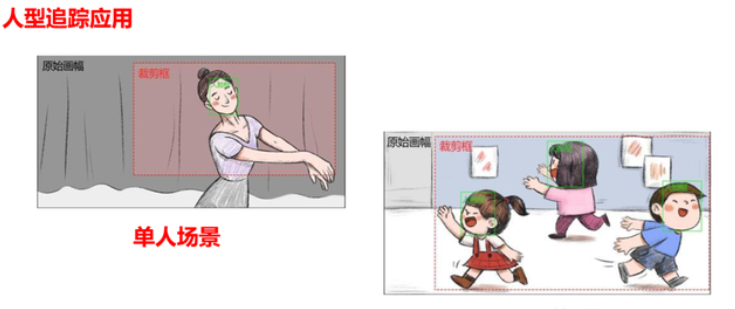

- 智能电视，多功能沉浸式娱乐体验

随着电视行业的发展，很多智能电视都配备了摄像头，它所搭载的功能也越来越丰富。智能USB摄像头方案可应用于智能电视的使用场景中，摄像头融入了丰富的AI功能，可以在大屏实现视频通话、AI健身、AI Kids、AI娱乐、智能识人、面部识别定制专属VR形象等多种功能。

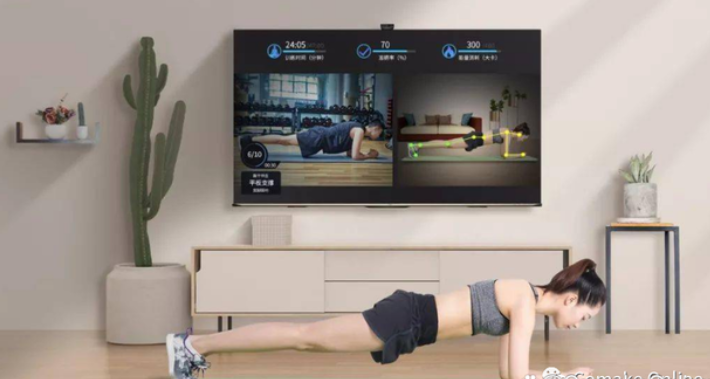

### 2. opencv的介绍及应用领域

- opencv简介

OpenCV是一个开源的跨平台计算机视觉库，可以运行在Linux、Windows、Android和Mac OS操作系统上。提供了Python、Ruby、MATLAB等语言的接口，并且实现了图像处理和计算机视觉方面的很多通用算法，可以给开发者调用。

- 应用领域

计算机视觉领域方向、人机互动、物体识别、图像分割、人脸识别、动作识别、运动跟踪、机器人、运动分析、机器视觉、结构分析、汽车安全驾驶

- OpenCV涉及的技术

（1）图像数据的操作： 分配、释放、复制、设置和转换。 图像是视频的输入输出I/O ，文件与摄像头的输入、图像和视频文件输出）。

（2）矩阵和向量的操作以及线性代数的算法程序：矩阵积、解方程、特征值以及奇异值等。

（3）各种动态数据结构：列表、队列、集合、树、图等。 

（4）基本的数字图像处理：滤波、边缘检测、角点检测、采样与差值、色彩转换、形态操作、直方图、图像金字塔等。

（5）结构分析：连接部件、轮廓处理、距离变换、各自距计算、模板匹配、Hough变换、多边形逼近、直线拟合、椭圆拟合、Delaunay 三角划分等。

（6）摄像头定标：发现与跟踪定标模式、定标、基本矩阵估计、齐次矩阵估计、立体对应。

（7）运动分析：光流、运动分割、跟踪。 

（8）目标识别：特征法、隐马尔可夫模型：HMM。

（9）基本的GUI：图像与视频显示、键盘和鼠标事件处理、滚动条。 

（10）图像标注：线、二次曲线、多边形、画文字。


## 任务实施

## 1. USB摄像头的连接和查看

在人工智能开发中，更多的是图像的识别，摄像头作为图像获取必不可少的设备，学习其使用方法变得很关键。

这里介绍的是USB摄像头的使用，当然还有其他的摄像头，比如网络摄像头，这些我们后面会介绍

### 1.1 USB摄像头的连接

USB摄像头，这个名字已经很明显，采用的就是USB接口的连接方式，而USB的接口，在开发板上有四个，

两个USB2.0和两个USB3.0，这两种接口的区别就是支持USB3.0的设备接在USB3.0接口上速度会更快一些，所以通常建议使用USB3.0的接口来连接。


### 1.2 查看摄像头video设备

在linux中任何对象都是文件，查看当前是否有摄像头挂载到Debian上，可以在开发板命令行终端，执行下面的命令
```linux
!ls -ltrh /dev/video*
```
ls参数：
- -l： 列出文件的详细信息。
- -t： 以时间排序。
- -r： 对目录反向排序。
- -h： 显示出了文件的大小

`/dev/video*`：表示`/dev/`目录下所有以`video`为开头的文件

`/dev/video0`表示有一个摄像头挂载在开发板上，编号为`0`

**知识补充**

权限`crw`其中：
- c：表示字符设备文件
- r：表示可读权限
- w：表示可写权限

<font color=red size=3>动手练习1</font>

在`<1>`处，使用`ls`命令设置查看参数为`ltrh`，查看`/dev`目录下的所有`video`设备。

填写完成后执行代码，输出结果类似为`crw-rw---- 1 root video 81, 0 6月  18 18:25 /dev/video0`，说明填写正确。

In [ ]:
!<1>

<details>
<summary><font color=red size=3>点击查看动手练习1答案</font></summary>
<pre><code>

```bash
!ls -ltrh /dev/video*
```
</code></pre>
</details>

## 2. opencv调用摄像头的基本使用

已经查看到摄像头信息，接下来使用opencv从USB摄像头读取图像，并在开发板中显示出来。

使用之前需要安装opencv的包，命令为：`pip3 install opencv-python`，默认板子上已经集成了opencv包

### 2.1 导入cv2并查看版本

`opencv-python` 在python的编码使用中，名称叫做 cv2。

`cv2`实现图像处理和计算机视觉方面的很多通用算法。

In [ ]:
import cv2
import time

cv2.__version__

### 2.2 利用opencv打开摄像头

要想读取摄像头的图片，则需要打开摄像头，而`VideoCapture`就是创建一个实例对象，并打开摄像头

创建VideoCapture对象的时候，我们需要传入一个合适的摄像头编号。

`cv2.VideoCapture(X)`

参数说明:

VideCapture接受的参数为序号
- 0 : 默认为系统插入的第一个摄像头，笔记本上是自带的那个摄像头
- 1 : USB摄像头2
- 2 ：USB摄像头3 以此类推
- -1：代表最新插入的USB设备

<font color=red size=3>动手练习2</font>

在`<1>`处，请根据以上信息，实例化一个对象来读取编号为`0`的摄像头, 并赋值给`cap`, 并打印结果。

输出结果类似为`<VideoCapture 0x7f73a0ead0>`的`VideoCapture`实例对象地址，说明填写正确。

In [ ]:
cap = <1>
print(cap)

<details>
<summary><font color=red size=3>点击查看动手练习2答案</font></summary>
<pre><code>

```python
cap = cv2.VideoCapture(0)
print(cap)
```
</code></pre>
</details>

### 2.3 查看Video Capture是否已经打开

实例化`VideoCapture`对象后，摄像头会自动打开

使用`cap.isOpened()`方法查看摄像头状态

若摄像头已打开则返回`True`，否则返回`False`

In [ ]:
print("摄像头是否已经打开 ？ {}".format(cap.isOpened()))

### 2.4 设置显示画面

接下来利用`cap.set`方法对窗口像素进行设置

` cap.set(propId, value)`

参数说明：

- `propId`表示VideoCaptureProperties中的属性标识符，
  - `cv2.CAP_PROP_FRAME_WIDTH`表示设置摄像头采集画面宽的像素大小
  - `cv2.CAP_PROP_FRAME_HEIGHT`表示设置摄像头采集画面高的像素大小
- `value`表示属性标识符的值，下面代码中，把采集画面像素宽度设置为1920，高度设置为1080;
  - 但是通常我们用于深度学习的更多是640*480

In [ ]:
# 画面宽度设定为 1920
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)

# 画面高度度设定为 1080
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)

### 2.5 创建显示窗口

`cv2.namedWindow(winname, flags)`：构建视频的窗口，用于放置图片

参数说明：
- `winname`：表示窗口的名字,可用作窗口标识符的窗口名称。
- `flags`：用于设置窗口的属性，常用属性如下
  - `WINDOW_NORMAL`：可以调整大小窗口
  - `WINDOW_KEEPRATIO`：保持图像比例
  - `WINDOW_GUI_EXPANDED`：绘制一个新的增强GUI窗口
  
下面创建一个名为`image_win`的窗口，设置窗口属性为可调整大小，保持图像比例，绘制窗口

In [ ]:
cv2.namedWindow('image_win',flags=cv2.WINDOW_NORMAL | cv2.WINDOW_KEEPRATIO | cv2.WINDOW_GUI_EXPANDED)
cv2.setWindowProperty('image_win', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN) # 全屏展示

### 2.6 读取图像

使用`cap.read()` 获取一帧图片，`cap.read()`返回值有两个，分别赋值给`ret`，`frame`
- `ret`：若画面读取成功，则返回True，反之返回False
- `frame`：是读取到的图片对象(numpy的ndarray格式)

<font color=red size=3>动手练习3</font>

在`<1>`处，请根据以上信息，来读取一张图像，赋值给`ret`，`frame`两个参数。

填写完成后执行以下代码，`ret`输出结果为`True`，说明填写正确。

In [ ]:
ret, frame = <1>
print(ret)

<details>
<summary><font color=red size=3>点击查看动手练习3答案</font></summary>
<pre><code>

```python
ret, frame = cap.read()
print(ret)
```
</code></pre>
</details>

### 2.7 显示图片

- `cv2.imshow(winname, mat)`函数可以在窗口中显示图像。

  参数
  - `winname`：窗口名称（也就是我们对话框的名称），它是一个字符串类型。
  - `mat`：是每一帧的画面图像。可以创建任意数量的窗口，但必须使用不同的窗口名称。
         
- `cv2.waitKey`：`waitkey`控制着`imshow`的持续时间，
  - 当`imshow`之后不跟`waitkey`时，相当于没有给`imshow`提供时间展示图像，只会有一个空窗口一闪而过。
  - `cv2.waitKey(100)`表示窗口中显示图像时间为100毫秒
  - `cv2.imshow`之后一定要跟`cv2.waitKey`函数

<font color=red size=3>动手练习4</font>

1. 在`<1>`处，请根据以上信息来显示图片，将`frame`图片放入之前创建的`image_win`窗口中。
2. 在`<2>`处，请用`cv2.waitKey`设置窗口显示时间为5000毫秒。

填写完成后执行代码，在显示屏上能够正常的显示图片，说明填写正确。

In [ ]:
<1>
<2>

<details>
<summary><font color=red size=3>点击查看动手练习4答案</font></summary>
<pre><code>

```python
cv2.imshow('image_win',frame)
cv2.waitKey(5000)
```
</code></pre>
</details>

### 2.8 保存图片

`cv2.imwrite(filename, img)`

  参数说明：
  - `filename`：要保存的文件名，
  - `img`：要保存的图像。

<font color=red size=3>动手练习5</font>

1. 在`<1>`处，请根据以上信息，保存`frame`图片，命名为`图像保存.png`，图片默认保存路径为当前路径。

可以通过输入命令`!ls`来查看当前路径是否有刚刚保存的图片;或者直接可以看左侧的项目路径下的图片

In [ ]:
<1>
!ls *.png

<details>
<summary><font color=red size=3>点击查看动手练习5答案</font></summary>
<pre><code>

```python
cv2.imwrite('图像保存.png', frame)
!ls *.png
```
</code></pre>
</details>

### 2.9 释放资源

- `cap.release()`：停止捕获视频，用`cv2.VideoCapture(0)`创建对象，操作结束后要用`cap.release()`来释放资源，否则会占用摄像头导致摄像头无法被其他程序使用。

- `cv2.destroyAllWindows()`：用来删除所有窗口

In [ ]:
# 释放VideoCapture
cap.release()
# 销毁所有的窗口
cv2.destroyAllWindows()

### 2.10 动手实验</font>

<font color=red size=3>动手练习6</font>

按照以下要求完成实验：
1. 在`<1>`处，实例化一个`VideoCapture`对象赋值给`cap`，设置休息时间为2秒
2. 在`<2>`处，使用`cap.set`设置显示画面像素，宽度为`1280`，高度为`800`
3. 在`<3>`处，使用`cv2.namedWindow`创建显示窗口命名为`image_win`,属性设置为`可调整大小`，`保持图像比例`
4. 在`<4>`处，使用`cap.read()`读取图像将返回值赋值给`ret`和`frame`
5. 在`<5>`处，使用`cv2.imshow`在窗口`image_win`中显示图像`frame`，设置`cv2.waitKey()`为5000毫秒
6. 在`<6>`处，使用`cv2.imwrite`保存`frame`图像，命名为`图像保存2.png`
7. 在`<7>`处，使用`cap.release()`和`cv2.destroyAllWindows()`资源释放

<font color=red>完成实验后，在当前路径下能够查看到命名为`图像保存2.png`的图像，则表示实验完成。

In [ ]:
# 完成代码
# 打开摄像头
<1>
print(cap.isOpened())

#设置画面像素
<2>

#构建视频的窗口
<3>

#读取摄像头图像
<4>

#更新窗口“image_win”中的图片
<5>
#用waitKey使图片显示5000ms
<5>

#保存图片
<6>

#释放VideoCapture
<7>
#销毁所有的窗口
<7>

<details>
<summary><font color=red size=3>点击查看动手练习6答案</font></summary>
<pre><code>

```python
# 打开摄像头
cap = cv2.VideoCapture(0)  
time.sleep(2)
print(cap.isOpened())

cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 800)

#构建视频的窗口
cv2.namedWindow('image_win',flags=cv2.WINDOW_NORMAL | cv2.WINDOW_KEEPRATIO )
cv2.setWindowProperty('image_win', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN) # 全屏展示

#读取摄像头图像
ret, frame = cap.read()

#更新窗口“image_win”中的图片
cv2.imshow('image_win',frame)
#用waitKey使图片显示5000ms
cv2.waitKey(5000)

#保存图片
cv2.imwrite("图像保存2.png", frame)

#释放VideoCapture
cap.release()
#销毁所有的窗口
cv2.destroyAllWindows()
```
</code></pre>
</details>

## 3. opencv利用线程的方式实现视频流

### 3.1 初识线程

进程是由若干线程组成的，一个进程至少有一个线程。

多任务可以由多进程完成，也可以由一个进程内的多线程完成，每条线程并行执行不同的任务。

由于线程是操作系统直接支持的执行单元，因此，高级语言通常都内置多线程的支持，Python也不例外，并且，Python的线程是真正的Posix Thread，而不是模拟出来的线程。

Python的标准库提供了两个模块：`_thread`和`threading`，`_thread`是低级模块，`threading`是高级模块，对`_thread`进行了封装。绝大多数情况下，我们只需要使用`threading`这个高级模块。

`threading`模块中最核心的内容是`Thread`这个类。

创建`Thread`对象,然后执行线程，每个`Thread`对象代表一个线程，每个线程可以让程序处理不同的任务，这就是多线程编程。

### 3.2 导入相应的包

- `threading`：threading模块提供了管理多个线程执行的API。

In [ ]:
import cv2
import threading
import time

### 3.3 编写线程类

直接从Thread继承，创建一个新的class，把线程执行的代码放到这个新的 class里。

即编写一个自定义类继承`Thread`，然后复写`run()`方法，在`run()`方法中编写任务处理代码，然后创建这个`Thread`的子类。

将函数封装成线程类，便于线程的调用与停止，大多用于这种方式来启动线程，属于面向对象编程。

- `self`：Python中就规定，函数的第一个参数，就必须是实例对象本身，并且建议，约定俗成，把其名字写为`self`,以`self`为前缀的变量都可供类中的所有方法使用。
- `def __init__(self)`：在实例化类时定义变量
  - `super`：函数是用于调用父类(超类)的一个方法。这里表示继承线程类`threading.Thread`。
- `def run(self)`：把要执行的代码写到run函数里面，线程在创建后，通过`.start()`会直接运行run函数

**退出线程的方式：**在类中定义标志位，通过编写`stop`函数来控制标志位，达到退出循环。 这样就能做到退出线程了。 

- `def stop(self)`：线程停止函数，用于控制标志位变量，从而达到控制线程

In [ ]:
class videoThread(threading.Thread):
    def __init__(self):
        super(videoThread, self).__init__()
        self.working = True  # 循环标志位
        self.running = False # 判断循环是否中止
        self.cap = cv2.VideoCapture(0)  # 打开摄像头
        if not self.cap.isOpened():
            print("Cannot open camera")
        else:
            print('摄像头已打开')
        # 画面宽度设定为 1920   高度度设定为 1080
        self.cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920)
        self.cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
        
    def run(self):
        self.running = True
        # 构建视频的窗口
        cv2.namedWindow('image_win',flags=cv2.WINDOW_NORMAL | cv2.WINDOW_KEEPRATIO | cv2.WINDOW_GUI_EXPANDED)
        cv2.setWindowProperty('image_win', cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN) # 全屏展示
        while self.working:
            # 读取摄像头图像
            ret, frame = self.cap.read()
            if not ret:
                print("图像获取失败，请按照说明进行问题排查")
                break
                
            # 更新窗口“image_win”中的图片
            cv2.imshow('image_win',frame)
            # 等待按键事件发生 等待1ms
            cv2.waitKey(1)
        self.running = False
        
    def stop(self):
        # 停止循环获取图像
        self.working = False
        # 循环未中止时等待
        while self.running:
            cv2.waitKey(1)
        # 释放VideoCapture
        self.cap.release()
        # 销毁所有的窗口
        cv2.destroyAllWindows()
        print("退出线程")

### 3.4 启动线程

实例化一个`videoThread()`线程类，实例化对象为`a`

线程对象`a`调用`start()`方法, 开始执行`videoThread()`线程类中的`run()`函数。

In [ ]:
a = videoThread()
a.start()

### 3.5 停止线程

实例化对象`a`调用`videoThread()`线程类中的`stop()`函数，来退出线程

In [ ]:
a.stop()